In [19]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns



# Libraries and packages for text (pre-)processing 
import string
import re
import nltk


from collections import defaultdict
from wordcloud import STOPWORDS

In [41]:
import pandas as pd

spam = pd.read_csv('./spam.csv', encoding='latin-1',      engine='python',   on_bad_lines='skip')

spam = spam[['v1', 'v2']]
spam.columns = ['target', 'text']

spam['target'] = spam['target'].map({'ham': 0, 'spam': 1})

spam['text'] = spam['text'].astype(str)



In [42]:
spam

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [43]:
print(spam['target'].unique())  # must be [0, 1]
print(spam.shape)

[0 1]
(5572, 2)


In [44]:
from sklearn.model_selection import train_test_split


train, test = train_test_split(spam, test_size=0.3, random_state=42, stratify=spam.target)
print("TRAIN size:", len(train))
print("TEST size:", len(test))


TRAIN size: 3900
TEST size: 1672


In [45]:
train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)


In [59]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')
# subm = pd.read_csv('./sample_submission.csv')

text_col = 'text'
target = 'target'
display(train.shape, train.head())



(3900, 2)

,target,text
0,1,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ..."
1,0,I dont. Can you send it to me. Plus how's mode.
2,0,Aah bless! How's your arm?
3,0,Oh k. . I will come tomorrow
4,0,Yup ok...


In [60]:
# train = pd.read_csv('./data/train_clean.csv')
# test = pd.read_csv('./data/test_clean.csv')
# # subm = pd.read_csv('./data/sample_submission.csv')

# text_col = 'text_clean'
# target = 'target'
# display(train.shape, train.head())



**Target Dist**

**Number of characters in tweets**

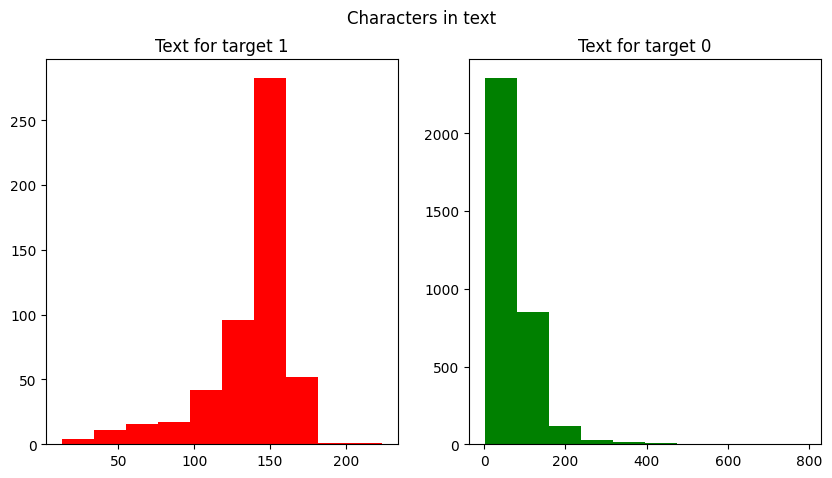

In [61]:


fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
train_len=train[train['target']==1][text_col].str.len()
ax1.hist(train_len,color='red')
ax1.set_title('Text for target 1')
train_len=train[train['target']==0][text_col].str.len()
ax2.hist(train_len,color='green')
ax2.set_title('Text for target 0')
fig.suptitle('Characters in text')
plt.show()





The distribution of both seems to be almost same.

**Number of words**

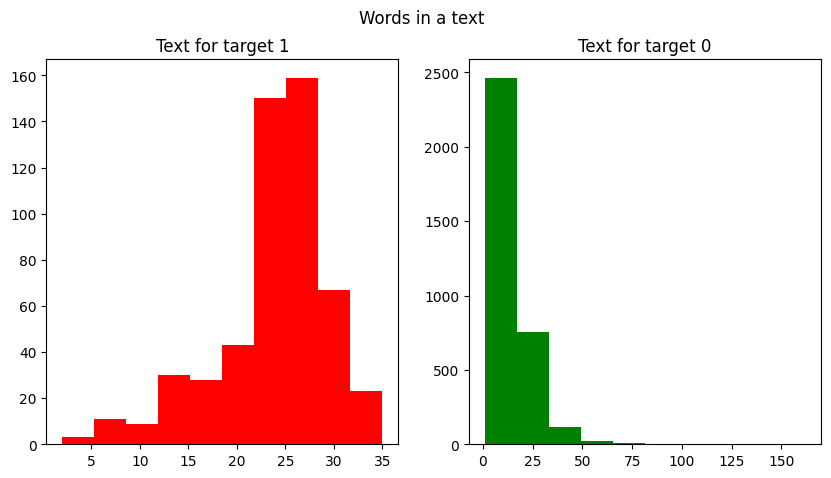

In [62]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
train_len=train[train['target']==1][text_col].str.split().map(lambda x: len(x))
ax1.hist(train_len,color='red')
ax1.set_title('Text for target 1')
train_len=train[train['target']==0][text_col].str.split().map(lambda x: len(x))
ax2.hist(train_len,color='green')
ax2.set_title('Text for target 0')
fig.suptitle('Words in a text')
plt.show()

**Average word length**

Text(0.5, 0.98, 'Average word length in each text')

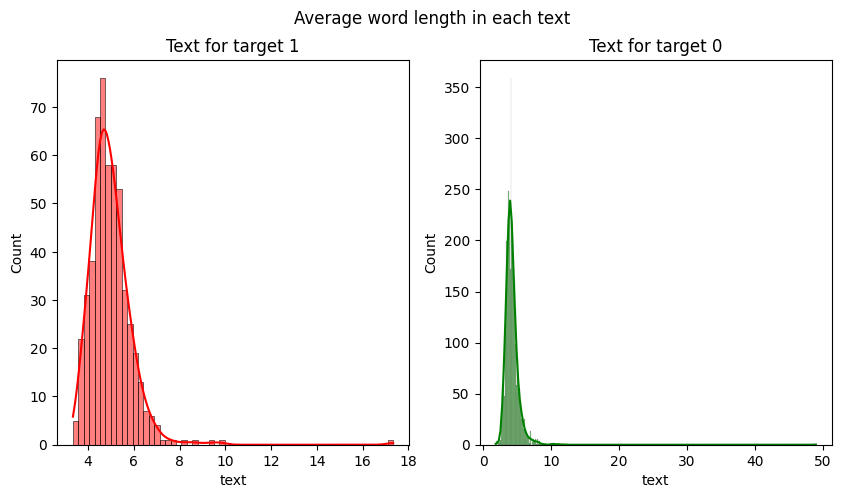

In [63]:


fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
word=train[train['target']==1][text_col].str.split().apply(lambda x : [len(i) for i in x])
sns.histplot(word.map(lambda x: np.mean(x)), ax=ax1, color='red', kde=True)
ax1.set_title('Text for target 1')


word=train[train['target']==0][text_col].str.split().apply(lambda x : [len(i) for i in x])
sns.histplot(word.map(lambda x: np.mean(x)), ax=ax2, color='green', kde=True)
ax2.set_title('Text for target 0')
fig.suptitle('Average word length in each text')



**Common stopwords in tweets**

In [64]:
# Function to create corpus from a dataframe for a given target
def create_corpus(df, text_column, target):
    corpus = []
    for text in df[df['target'] == target][text_column].str.split():
        corpus.extend(text)
    return corpus

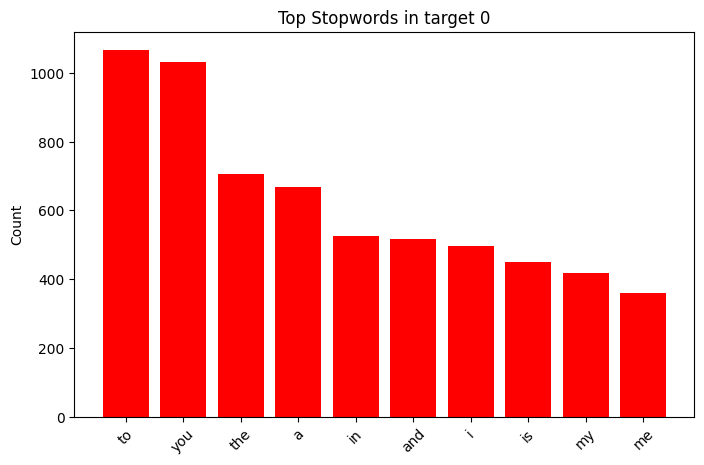

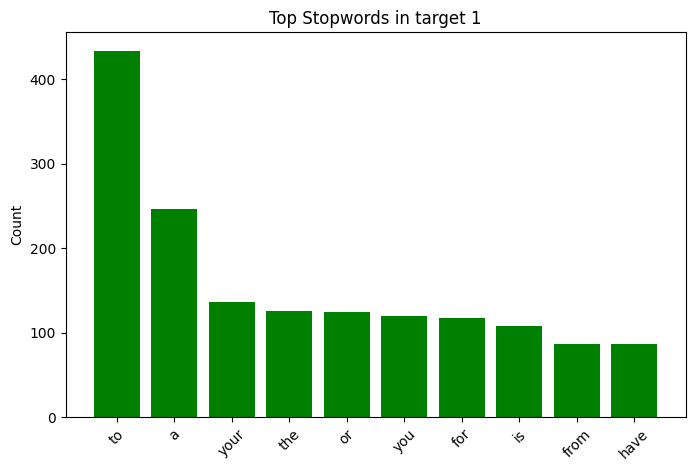

In [65]:

import matplotlib.pyplot as plt



# Function to get top N stopwords
def top_stopwords(corpus, n=10):
    dic = defaultdict(int)
    for word in corpus:
        if word in STOPWORDS:
            dic[word] += 1
    top = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:n]
    return zip(*top)  # returns x, y

# Plotting function
def plot_top_stopwords(df, text_column, target, color, title):
    corpus = create_corpus(df, text_column, target)
    x, y = top_stopwords(corpus)
    plt.figure(figsize=(8,5))
    plt.bar(x, y, color=color)
    plt.title(title)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# Plot for target 0
plot_top_stopwords(train, text_col, 0, color='red', title='Top Stopwords in target 0')

# Plot for target 1
plot_top_stopwords(train, text_col, 1, color='green', title='Top Stopwords in target 1')

In both of them,"the" dominates which is followed by "a" in class 0 and "in" in class 1.

**Analyzing punctuations.**

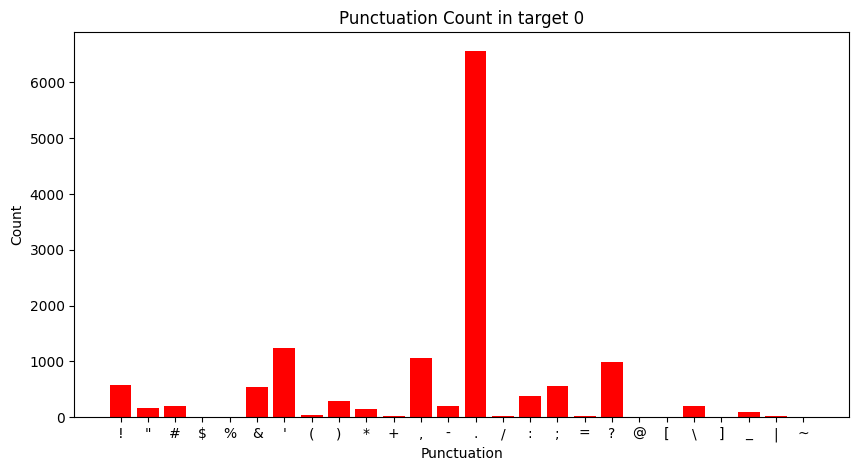

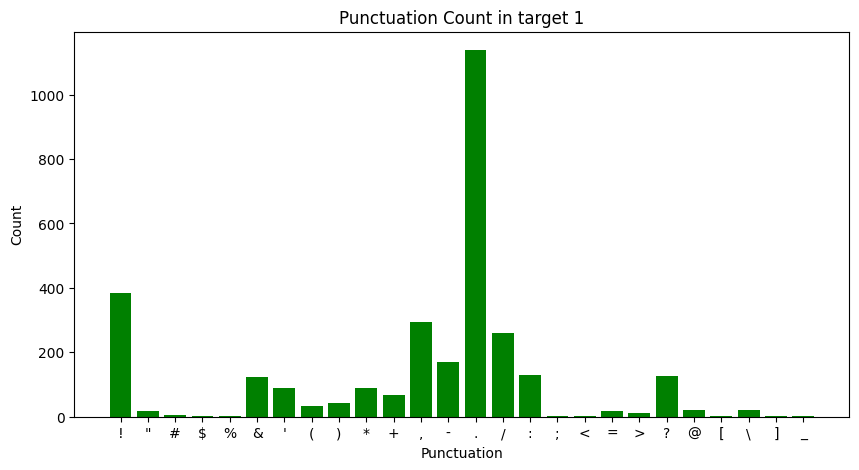

In [66]:
from collections import defaultdict
import string
import matplotlib.pyplot as plt

# Function to count special characters (punctuation) in a corpus
def count_punctuation(corpus):
    dic = defaultdict(int)
    special = string.punctuation
    for word in corpus:
        for char in word:  # check each character in the word
            if char in special:
                dic[char] += 1
    if dic:
        return zip(*sorted(dic.items(), key=lambda x: x[0]))  # sorted by symbol
    else:
        return [], []

# Plotting function for punctuation
def plot_punctuation(df, text_column, target, color, title):
    corpus = create_corpus(df, text_column, target)
    x, y = count_punctuation(corpus)
    if x and y:  # only plot if there is something
        plt.figure(figsize=(10,5))
        plt.bar(x, y, color=color)
        plt.title(title)
        plt.ylabel('Count')
        plt.xlabel('Punctuation')
        plt.show()
    else:
        print(f"No punctuation found for target {target}")



# Plot for target 0
plot_punctuation(train, text_col, 0, color='red', title='Punctuation Count in target 0')

# Plot for target 1
plot_punctuation(train, text_col, 1, color='green', title='Punctuation Count in target 1')

**Common words ?**

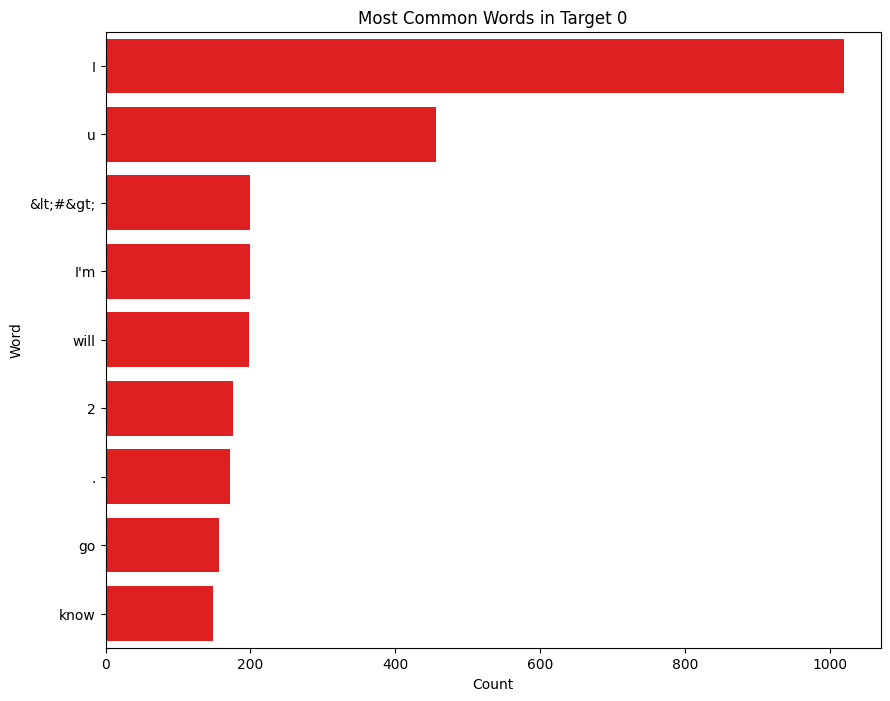

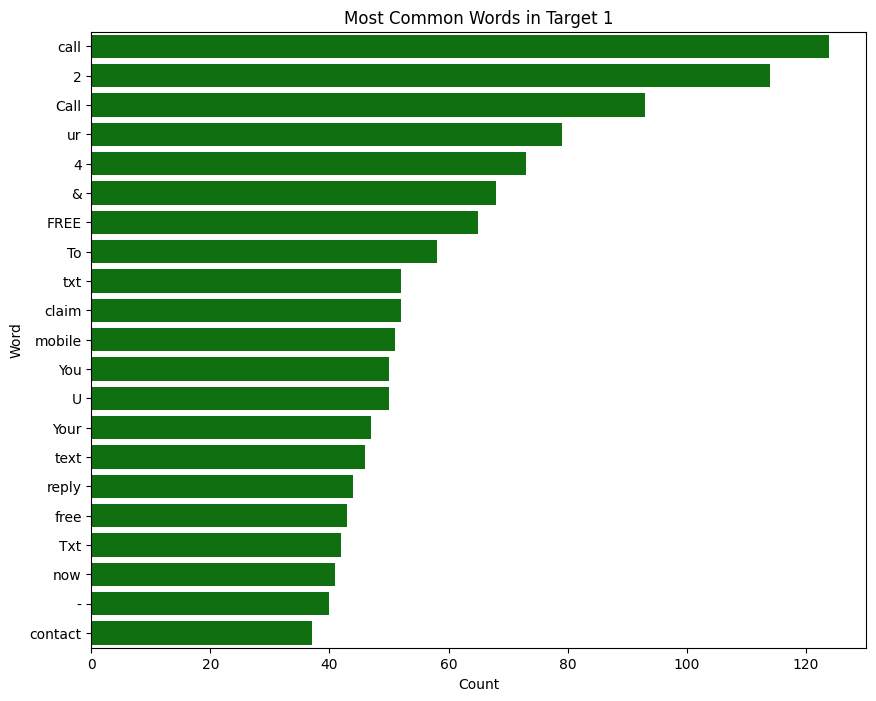

In [67]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

def plot_most_common_words(corpus, stopwords_list, top_n=40, color='blue', title='Most Common Words'):
    # Count words
    counter = Counter(corpus)
    most = counter.most_common()
    
    # Filter out stopwords
    x = []
    y = []
    for word, count in most[:top_n]:
        if word not in stopwords_list:
            x.append(word)
            y.append(count)
    
    # Plot
    plt.figure(figsize=(10,8))
    sns.barplot(x=y, y=x, color=color)
    plt.title(title)
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.show()

# Example usage for target 0
corpus_0 = create_corpus(train, text_col, 0)
plot_most_common_words(corpus_0, stopwords_list=STOPWORDS, top_n=40, color='red', title='Most Common Words in Target 0')

# Example usage for target 1
corpus_1 = create_corpus(train, text_col, 1)
plot_most_common_words(corpus_1, stopwords_list=STOPWORDS, top_n=40, color='green', title='Most Common Words in Target 1')

**Missing Values**

fill with specific words

KeyError: "['date', 'flag', 'user'] not in index"

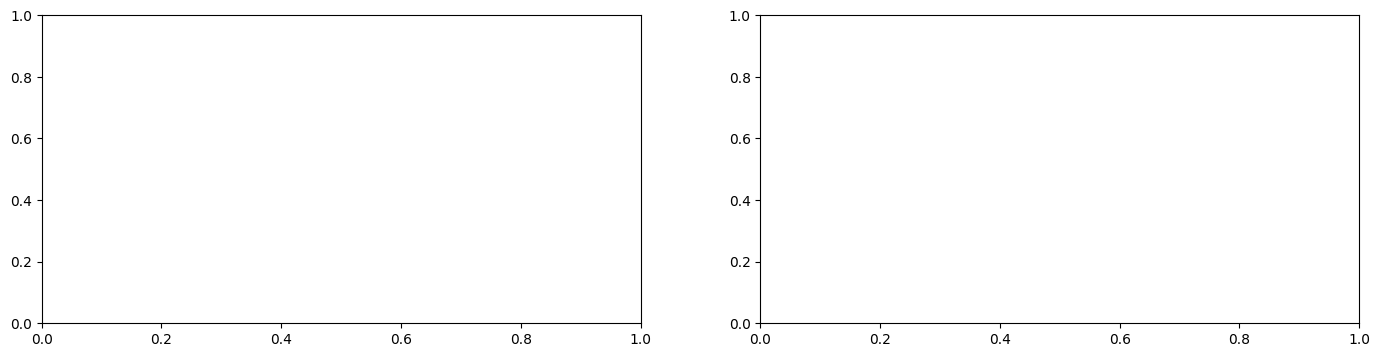

In [68]:
# Mssing columns
missing_cols = ['date', 'flag', 'user', 'target']


fig, axes = plt.subplots(ncols=2, figsize=(17, 4), dpi=100)

sns.barplot(x=train[missing_cols].isnull().sum().index, y=train[missing_cols].isnull().sum().values, ax=axes[0])
sns.barplot(x=test[missing_cols].isnull().sum().index, y=test[missing_cols].isnull().sum().values, ax=axes[1])

axes[0].set_ylabel('Missing Value Count', size=15, labelpad=20)
axes[0].tick_params(axis='x', labelsize=15)
axes[0].tick_params(axis='y', labelsize=15)
axes[1].tick_params(axis='x', labelsize=15)
axes[1].tick_params(axis='y', labelsize=15)

axes[0].set_title('Training Set', fontsize=13)
axes[1].set_title('Test Set', fontsize=13)

plt.show()

for df in [train, test]:
    for col in missing_cols:
        df[col] = df[col].fillna(f'no_{col}')

**Unique values**

In [77]:
cols = ['flag', 'user']
for col in cols:
    print(f'Number of unique values in {col} = {train[col].nunique()} (Training) - {test[col].nunique()} (Test)')

Number of unique values in flag = 1 (Training) - 1 (Test)
Number of unique values in user = 574045 (Training) - 215547 (Test)


In [ ]:
cols = ['user']

train_explore = train.copy()

for col in cols:
    train_explore[col + '_mean'] = train_explore.groupby(col)['target'].transform('mean') # explanation: for each value in the column, calculate the mean of the target and assign it to a new column

    fig = plt.figure(figsize=(8, 72), dpi=100)

    sns.countplot(y=train_explore.sort_values(by=col + '_mean', ascending=False)[col],
                  hue=train_explore.sort_values(by=col + '_mean', ascending=False)['target'])
    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=12)
    plt.legend(loc=1)
    plt.title(f'Target Distribution in {col}')
    plt.show()



del train_explore

**Meta Features**


- word_count number of words in text
- unique_word_count number of unique words in text
- stop_word_count number of stop words in text
- url_count number of urls in text
- mean_word_length average character count in words
- char_count number of characters in text
- punctuation_count number of punctuations in text
- hashtag_count number of hashtags (#) in text
- mention_count number of mentions (@) in text

In [69]:
from nltk.corpus import stopwords


STOPWORDS = set(stopwords.words('english'))

# word_count
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))
test['word_count'] = test['text'].apply(lambda x: len(str(x).split()))

# unique_word_count
train['unique_word_count'] = train['text'].apply(lambda x: len(set(str(x).split())))
test['unique_word_count'] = test['text'].apply(lambda x: len(set(str(x).split())))

# stop_word_count
train['stop_word_count'] = train['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))
test['stop_word_count'] = test['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))

# url_count
train['url_count'] = train['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))
test['url_count'] = test['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))

# mean_word_length
train['mean_word_length'] = train['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
test['mean_word_length'] = test['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# char_count
train['char_count'] = train['text'].apply(lambda x: len(str(x)))
test['char_count'] = test['text'].apply(lambda x: len(str(x)))

# punctuation_count
train['punctuation_count'] = train['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
test['punctuation_count'] = test['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# hashtag_count
train['hashtag_count'] = train['text'].apply(lambda x: len([c for c in str(x) if c == '#']))
test['hashtag_count'] = test['text'].apply(lambda x: len([c for c in str(x) if c == '#']))

# mention_count
train['mention_count'] = train['text'].apply(lambda x: len([c for c in str(x) if c == '@']))
test['mention_count'] = test['text'].apply(lambda x: len([c for c in str(x) if c == '@']))



In [70]:
train

,target,text,word_count,unique_word_count,stop_word_count,url_count,mean_word_length,char_count,punctuation_count,hashtag_count,mention_count
0,1,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ...",32,27,9,0,3.875000,155,4,0,0
1,0,I dont. Can you send it to me. Plus how's mode.,11,11,5,0,3.363636,47,4,0,0
2,0,Aah bless! How's your arm?,5,5,1,0,4.400000,26,3,0,0
3,0,Oh k. . I will come tomorrow,7,7,2,0,3.142857,28,2,0,0
4,0,Yup ok...,2,2,0,0,4.000000,9,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...
3895,0,Happy birthday to you....dear.with lots of lov...,8,8,2,0,6.500000,59,6,0,0
3896,0,what I meant to say is cant wait to see u agai...,18,17,8,0,3.888889,87,0,0,0
3897,0,"Sure, if I get an acknowledgement from you tha...",21,21,10,0,4.761905,120,2,0,0
3898,0,Nothing but we jus tot u would ask cos u ba gu...,32,28,7,0,3.750000,151,12,0,0


In [73]:
train[train['mean_word_length'] > 10]['text'].values[3]

'Free Msg: Ringtone!From: http://tms. widelive.com/index. wml?id=1b6a5ecef91ff9*37819&first=true18:0430-JUL-05'

All of the meta features have information about target as well, but some of them are not good enough such as url_count, hashtag_count and mention_count.

On the other hand, word_count, unique_word_count, stop_word_count, mean_word_length, char_count, punctuation_count have very different distributions for disaster and non-disaster tweets. Those features might be useful in models.

In [75]:
METAFEATURES = ['word_count', 'unique_word_count', 'stop_word_count', 'url_count', 'mean_word_length',
                'char_count', 'punctuation_count', 'hashtag_count', 'mention_count']

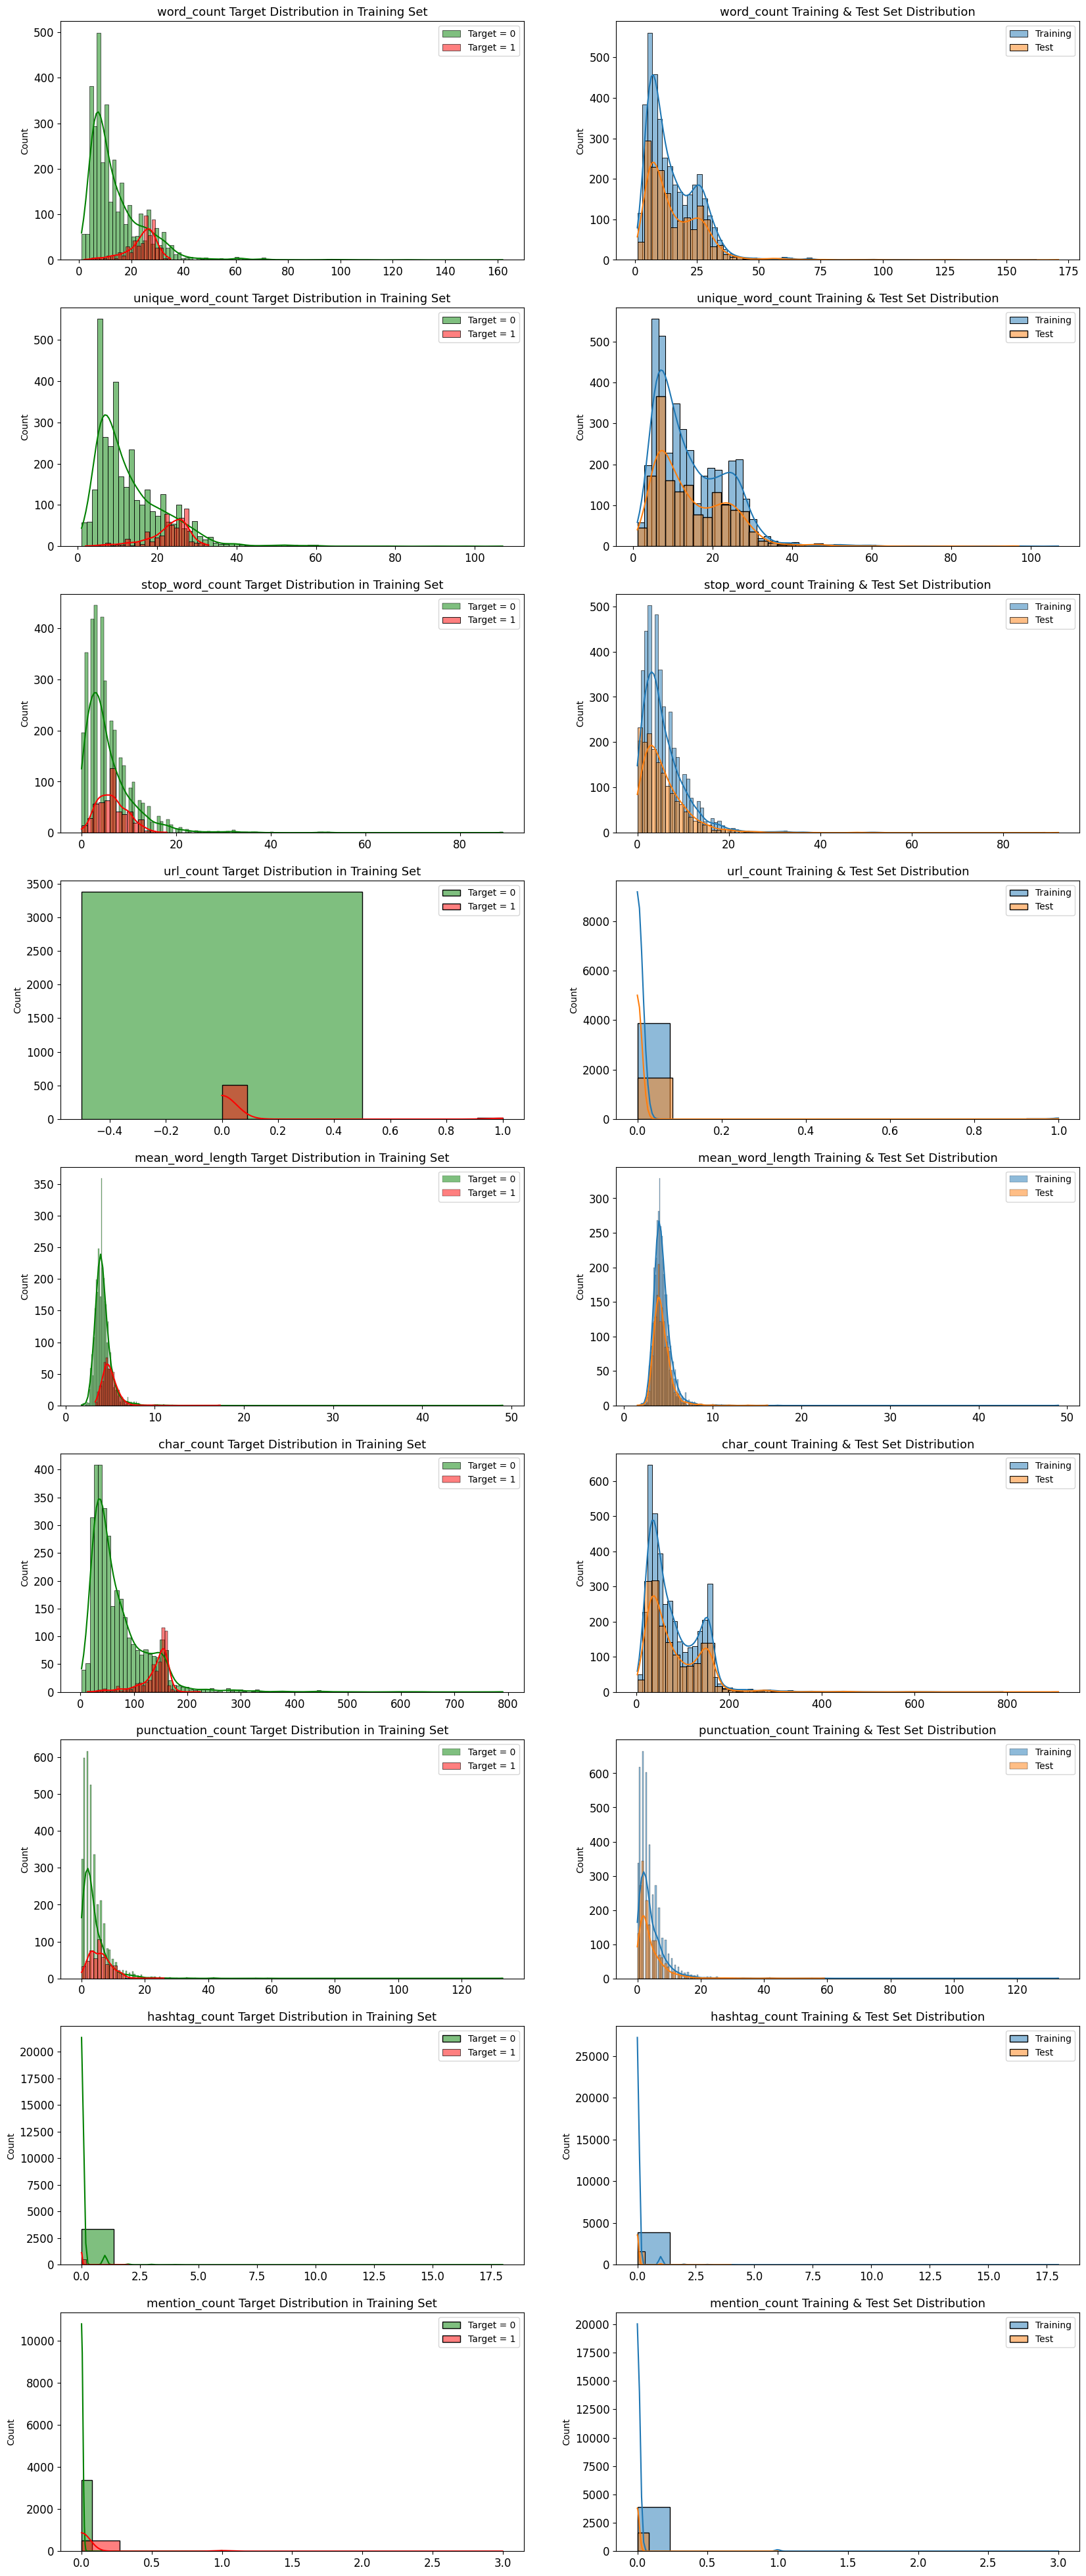

In [76]:



TARGET_1 = train['target'] == 1

fig, axes = plt.subplots(ncols=2, nrows=len(METAFEATURES), figsize=(20, 50), dpi=100)

for i, feature in enumerate(METAFEATURES):

    sns.histplot(train.loc[~TARGET_1][feature], label='Target = 0', ax=axes[i][0], color='green', kde=True)
    sns.histplot(train.loc[TARGET_1][feature], label='Target = 1', ax=axes[i][0], color='red', kde=True)

    sns.histplot(train[feature], label='Training', ax=axes[i][1], kde=True)
    sns.histplot(test[feature], label='Test', ax=axes[i][1], kde=True)
    
    for j in range(2):
        axes[i][j].set_xlabel('')
        axes[i][j].tick_params(axis='x', labelsize=12)
        axes[i][j].tick_params(axis='y', labelsize=12)
        axes[i][j].legend()
    
    axes[i][0].set_title(f'{feature} Target Distribution in Training Set', fontsize=13)
    axes[i][1].set_title(f'{feature} Training & Test Set Distribution', fontsize=13)

plt.show()



In [84]:
train[train['text'] == ':-) :-)']

,target,text,word_count,unique_word_count,stop_word_count,url_count,mean_word_length,char_count,punctuation_count,hashtag_count,mention_count
1897,0,:-) :-),2,1,0,0,3.0,7,6,0,0


**Mislabeled Samples**

There are 18 unique tweets in training set which are labeled differently in their duplicates. Those tweets are probably labeled by different people and they interpreted the meaning differently because some of them are not very clear. Tweets with two unique target values are relabeled since they can affect the training score.

In [22]:
df_mislabeled = train.groupby(['text']).nunique().sort_values(by='target', ascending=False)
df_mislabeled = df_mislabeled[df_mislabeled['target'] > 1]['target']
df_mislabeled.index.tolist()

["@Hebbie mornin hebbie  sun's shinin over here in germany too..not for much longer though..storms on the way ",
 '@LaurenConrad just remind fans they can watch it again at MTV.ca and MTV.com  im in Toronto and we had some audio issues ',
 'Good ole thai food at thai express sans bear..  ',
 ' nothing',
 "Good or bad news 1st? OK, bad - I've worked 100 hours in 7 days  UGH! Good - I'm going back to school  More paper, more options LOL",
 'painting ',
 "@cuspate  Daughter now on unlimited text tariff. Can't afford to be PAYG and reply to all her texts   Cheaper to buy new iPhone 3GS ",
 '@dsthestar1121 ',
 'oh you just texted  but I only got parts 2 and 3 so I dont know what he said  you will have to tell me tomorrow ok?',
 "@wetheTRAVIS oh no  I hope it doesn't hurt. Get a lollipop! i do everytime i go  yay ruining teeth after they fix them!",
 'goodnite to all  but lets c if i can get any sleep ',
 "@cinebo Well, it's Monday. The day you've been waiting for!  For the rest of us though

fix them manually

In [23]:
train['target_relabeled'] = train['target'].copy() 

train.loc[train['text'] == 'like for the music video I want some real action shit like burning buildings and police chases not some weak ben winston shit', 'target_relabeled'] = 0
train.loc[train['text'] == 'Hellfire is surrounded by desires so be careful and donÛªt let your desires control you! #Afterlife', 'target_relabeled'] = 0
train.loc[train['text'] == 'To fight bioterrorism sir.', 'target_relabeled'] = 0
train.loc[train['text'] == '.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4', 'target_relabeled'] = 1
train.loc[train['text'] == 'CLEARED:incident with injury:I-495  inner loop Exit 31 - MD 97/Georgia Ave Silver Spring', 'target_relabeled'] = 1
train.loc[train['text'] == '#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption', 'target_relabeled'] = 0
train.loc[train['text'] == 'In #islam saving a person is equal in reward to saving all humans! Islam is the opposite of terrorism!', 'target_relabeled'] = 0
train.loc[train['text'] == 'Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her\n \n#FARRAKHAN #QUOTE', 'target_relabeled'] = 1
train.loc[train['text'] == 'RT NotExplained: The only known image of infamous hijacker D.B. Cooper. http://t.co/JlzK2HdeTG', 'target_relabeled'] = 1
train.loc[train['text'] == "Mmmmmm I'm burning.... I'm burning buildings I'm building.... Oooooohhhh oooh ooh...", 'target_relabeled'] = 0
train.loc[train['text'] == "wowo--=== 12000 Nigerian refugees repatriated from Cameroon", 'target_relabeled'] = 0
train.loc[train['text'] == "He came to a land which was engulfed in tribal war and turned it into a land of peace i.e. Madinah. #ProphetMuhammad #islam", 'target_relabeled'] = 0
train.loc[train['text'] == "Hellfire! We donÛªt even want to think about it or mention it so letÛªs not do anything that leads to it #islam!", 'target_relabeled'] = 0
train.loc[train['text'] == "The Prophet (peace be upon him) said 'Save yourself from Hellfire even if it is by giving half a date in charity.'", 'target_relabeled'] = 0
train.loc[train['text'] == "Caution: breathing may be hazardous to your health.", 'target_relabeled'] = 1
train.loc[train['text'] == "I Pledge Allegiance To The P.O.P.E. And The Burning Buildings of Epic City. ??????", 'target_relabeled'] = 0
train.loc[train['text'] == "#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect", 'target_relabeled'] = 0
train.loc[train['text'] == "that horrible sinking feeling when youÛªve been at home on your phone for a while and you realise its been on 3G this whole time", 'target_relabeled'] = 0

**NGrams**

using CountVectorizer

add , stop_words=stop_words to remove stop_words

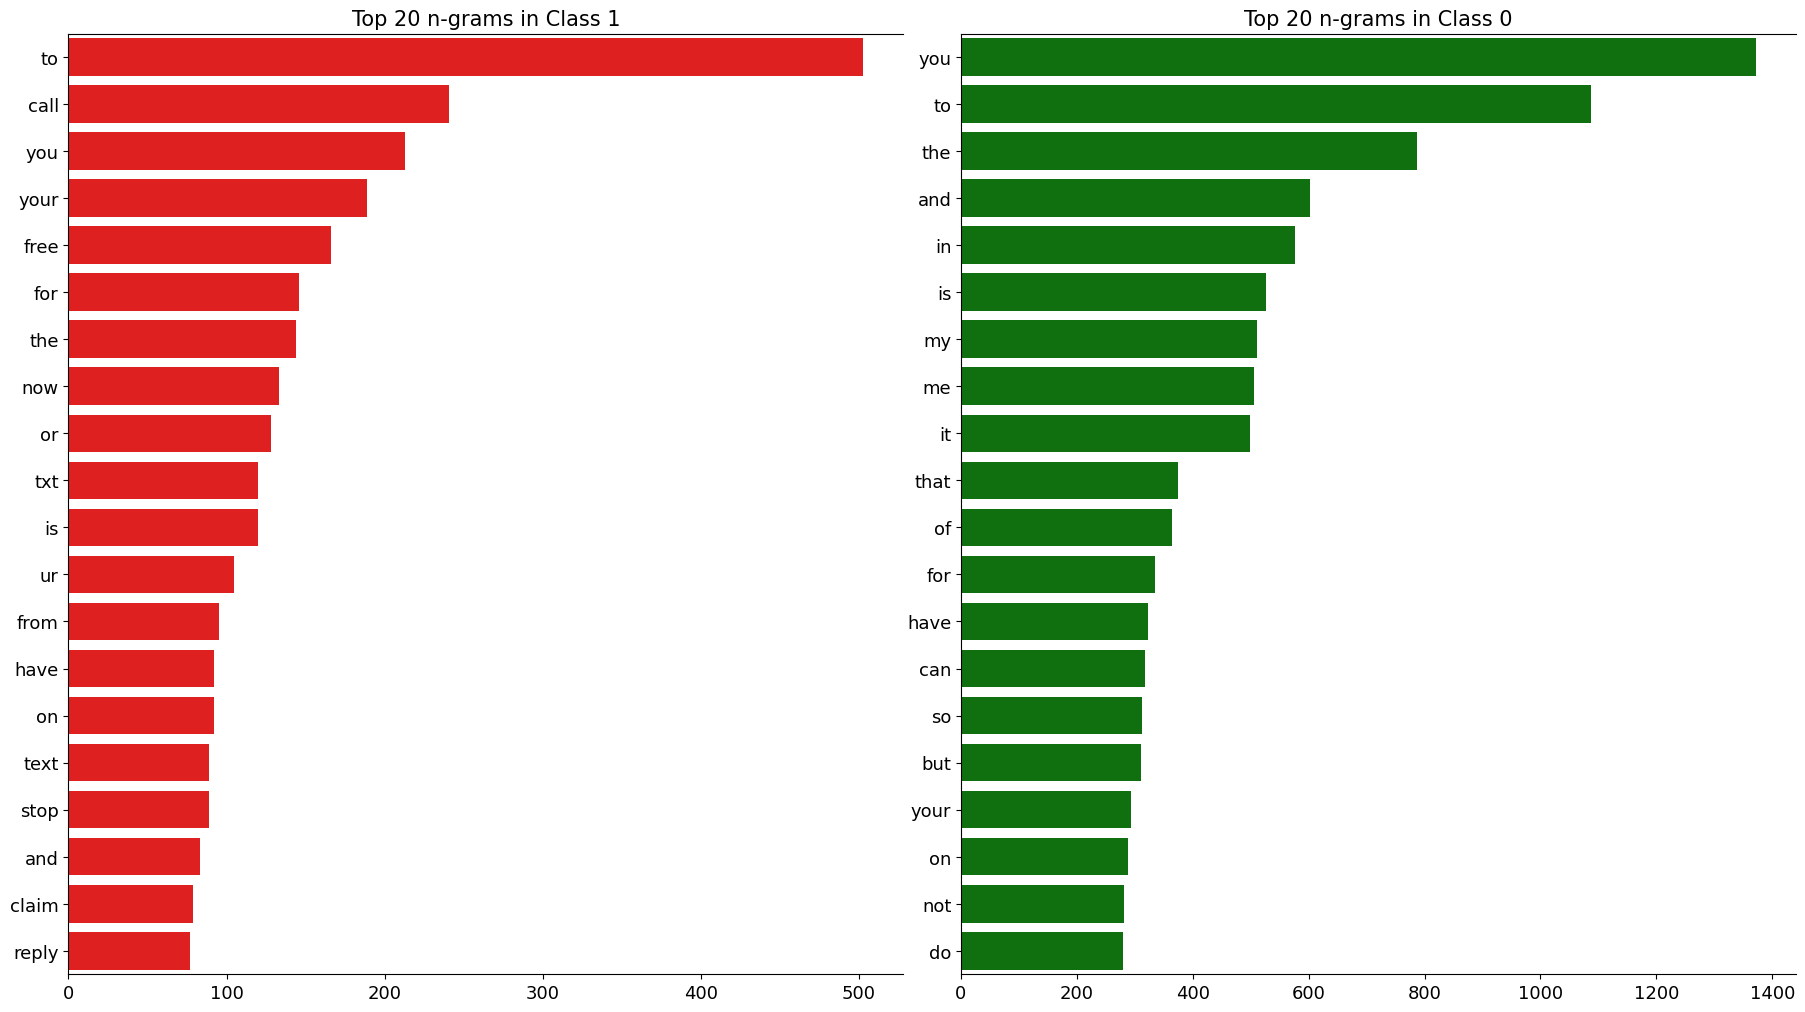

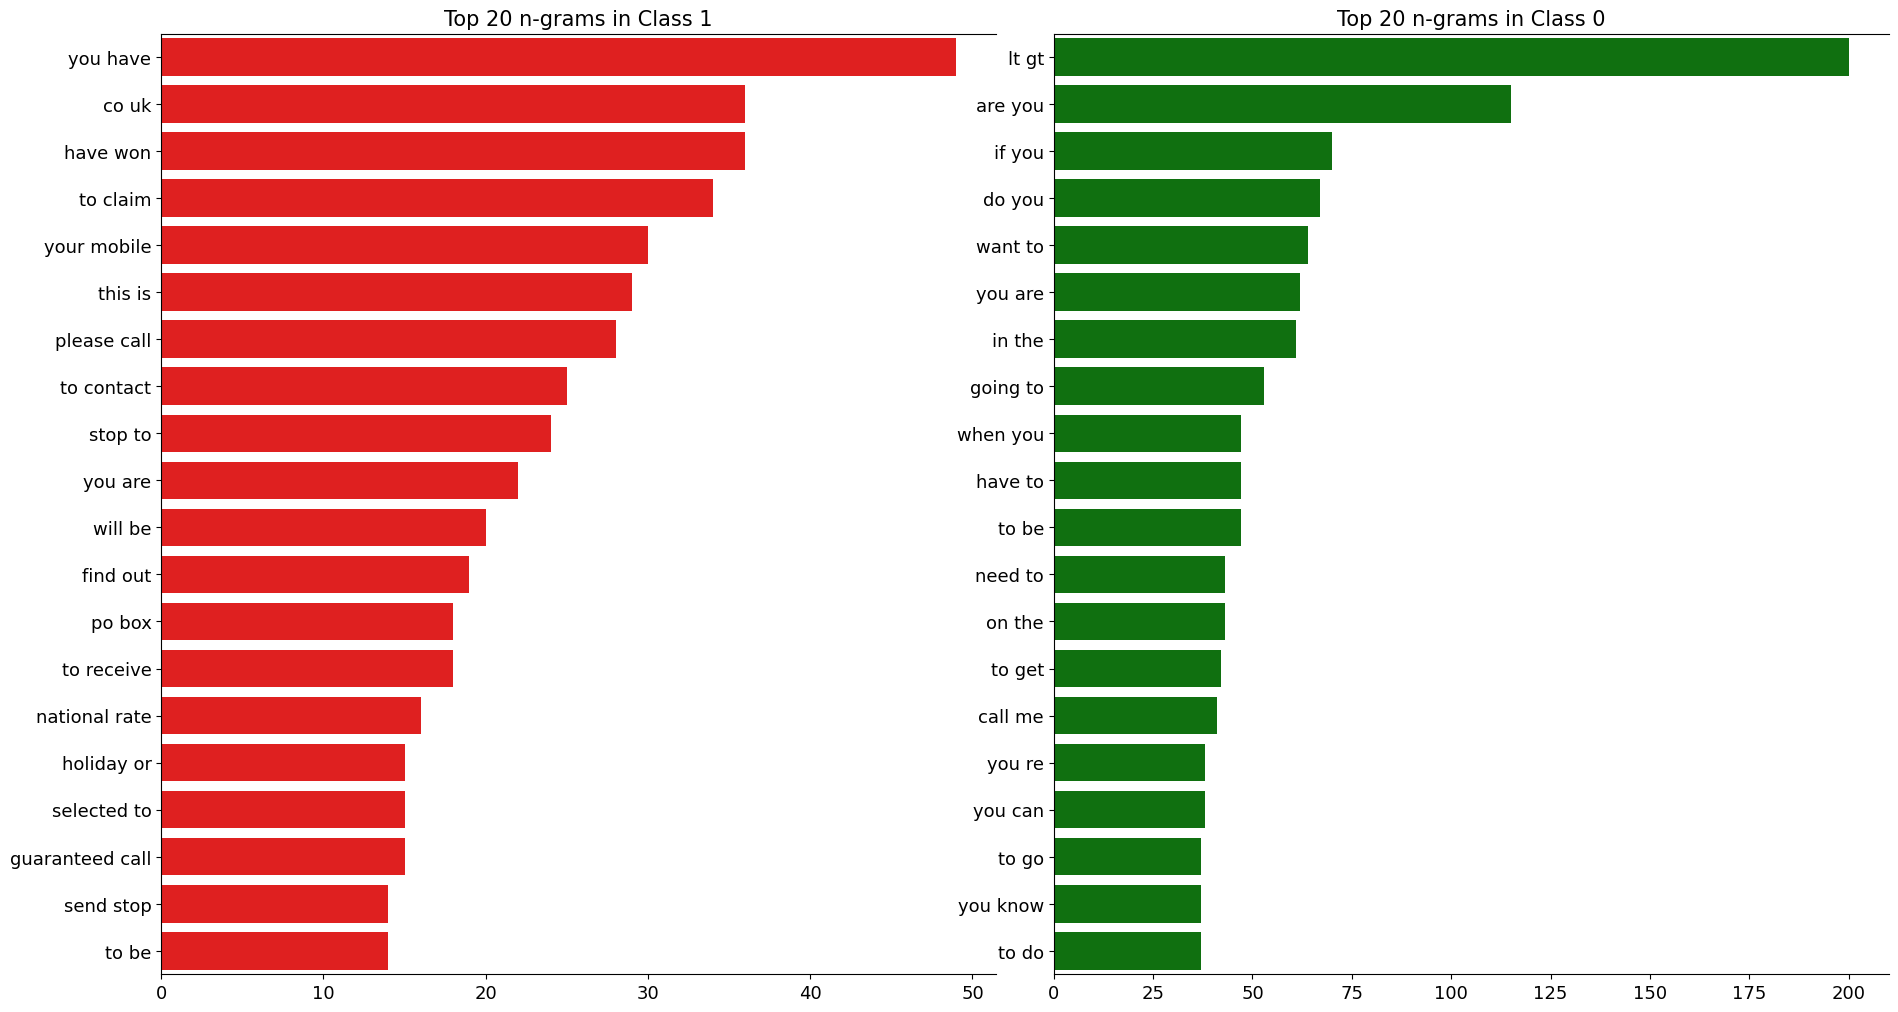

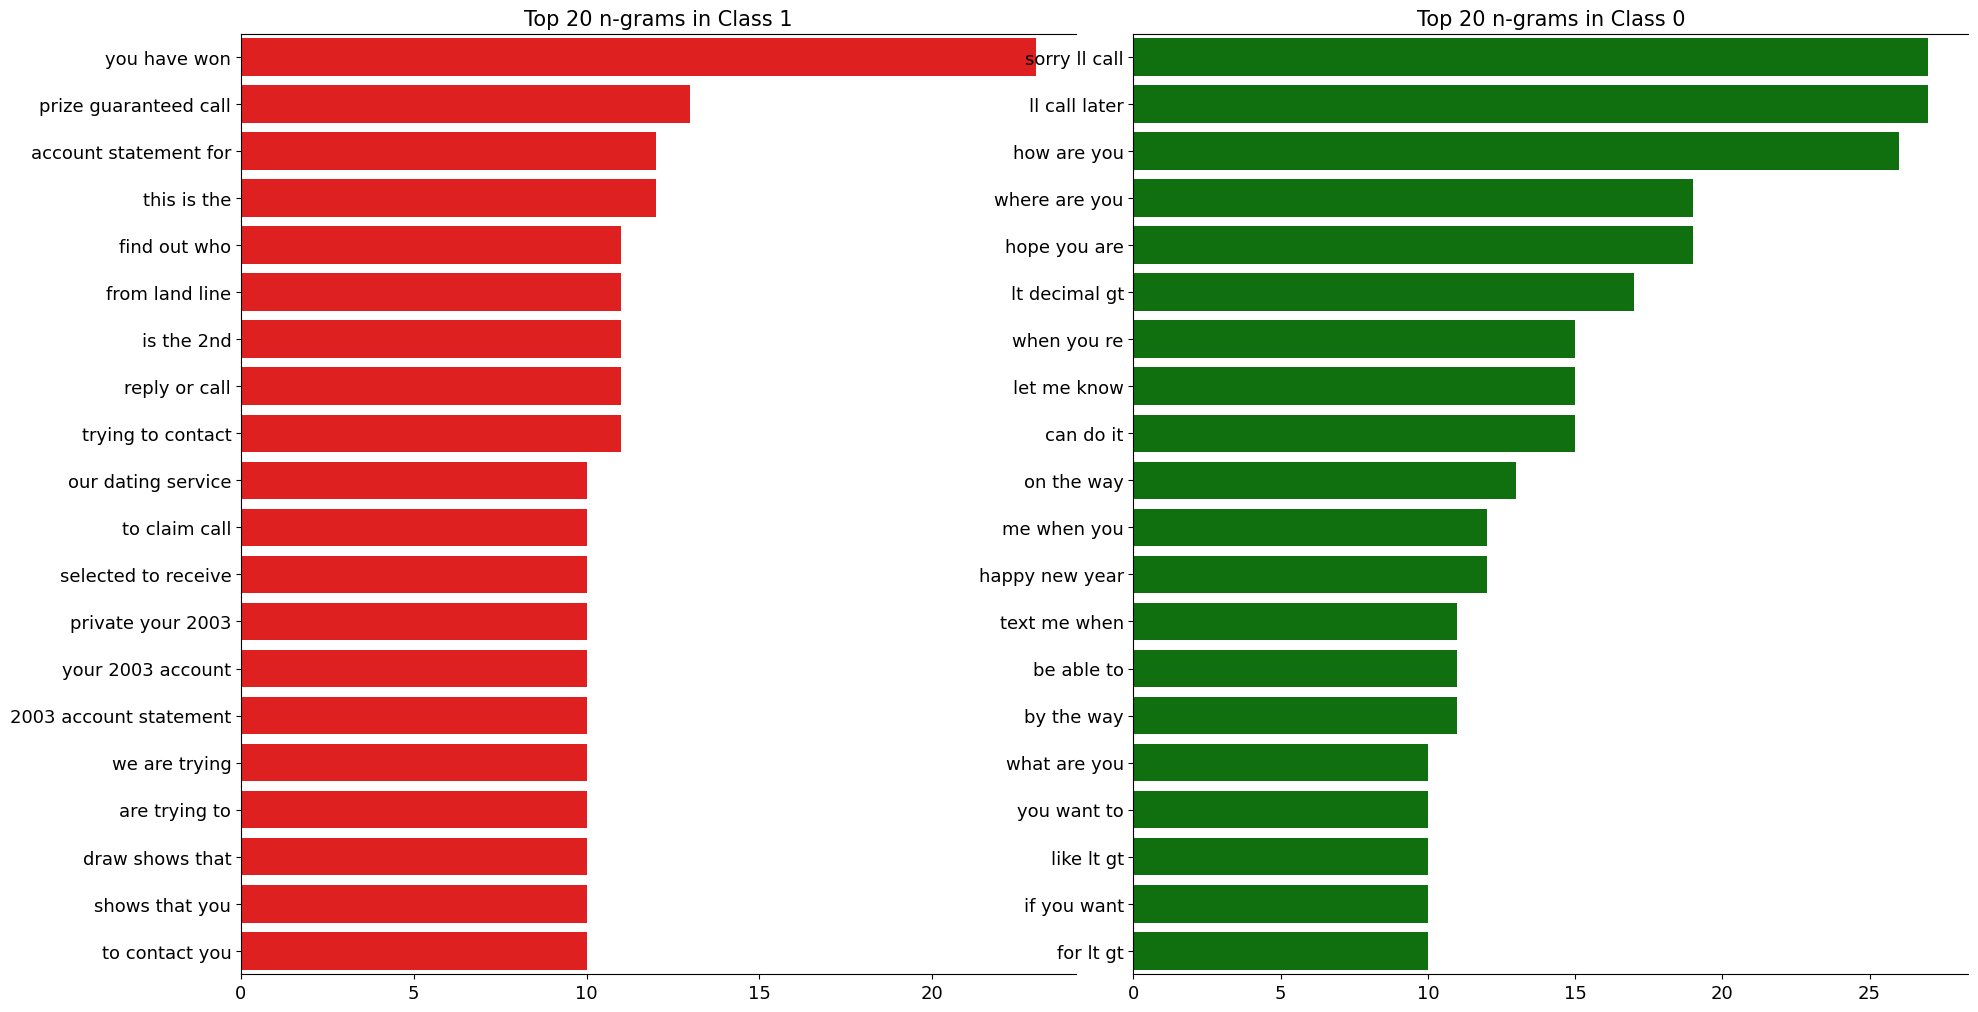

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top N n-grams using CountVectorizer
def get_top_ngrams(corpus, n_gram=(1,1), top_n=20, stop_words='english'):
    vectorizer = CountVectorizer(ngram_range=n_gram) # , stop_words=stop_words 
    bag_of_words = vectorizer.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame(words_freq, columns=['ngram', 'count'])

# General function to plot top n-grams for two subsets of data
def plot_top_ngrams(df, text_column, mask1, mask2, n_gram=(1,1), top_n=20, colors=('red','green'), titles=('Subset 1', 'Subset 2')):
    df1 = get_top_ngrams(df[mask1][text_column], n_gram=n_gram, top_n=top_n)
    df2 = get_top_ngrams(df[mask2][text_column], n_gram=n_gram, top_n=top_n)

    fig, axes = plt.subplots(ncols=2, figsize=(18, 10), dpi=100)
    plt.tight_layout()

    sns.barplot(y=df1['ngram'], x=df1['count'], ax=axes[0], color=colors[0])
    sns.barplot(y=df2['ngram'], x=df2['count'], ax=axes[1], color=colors[1])

    for ax in axes:
        ax.spines['right'].set_visible(False)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=13)
        ax.tick_params(axis='y', labelsize=13)

    axes[0].set_title(f'Top {top_n} n-grams in {titles[0]}', fontsize=15)
    axes[1].set_title(f'Top {top_n} n-grams in {titles[1]}', fontsize=15)
    
    plt.show()

# Example usage
mask_a = train['target'] == 1
mask_b = train['target'] == 0
plot_top_ngrams(train, text_col, mask_a, mask_b, n_gram=(1,1), top_n=20, colors=('red','green'), titles=('Class 1','Class 0'))
plot_top_ngrams(train, text_col, mask_a, mask_b, n_gram=(2,2), top_n=20, colors=('red','green'), titles=('Class 1','Class 0'))
plot_top_ngrams(train, text_col, mask_a, mask_b, n_gram=(3,3), top_n=20, colors=('red','green'), titles=('Class 1','Class 0'))

using Manual generate_ngrams approach

In [78]:


from collections import defaultdict


def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(' ') if token != '' if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [' '.join(ngram) for ngram in ngrams]


N = 100

# Unigrams
disaster_unigrams = defaultdict(int)
nondisaster_unigrams = defaultdict(int)




for tweet in train[TARGET_1]['text']:
    for word in generate_ngrams(tweet):
        disaster_unigrams[word] += 1
        
for tweet in train[~TARGET_1]['text']:
    for word in generate_ngrams(tweet):
        nondisaster_unigrams[word] += 1
        
df_disaster_unigrams = pd.DataFrame(sorted(disaster_unigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_unigrams = pd.DataFrame(sorted(nondisaster_unigrams.items(), key=lambda x: x[1])[::-1])

# Bigrams
disaster_bigrams = defaultdict(int)
nondisaster_bigrams = defaultdict(int)

for tweet in train[TARGET_1]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        disaster_bigrams[word] += 1
        
for tweet in train[~TARGET_1]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        nondisaster_bigrams[word] += 1
        
df_disaster_bigrams = pd.DataFrame(sorted(disaster_bigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_bigrams = pd.DataFrame(sorted(nondisaster_bigrams.items(), key=lambda x: x[1])[::-1])

# Trigrams
disaster_trigrams = defaultdict(int)
nondisaster_trigrams = defaultdict(int)

for tweet in train[TARGET_1]['text']:
    for word in generate_ngrams(tweet, n_gram=3):
        disaster_trigrams[word] += 1
        
for tweet in train[~TARGET_1]['text']:
    for word in generate_ngrams(tweet, n_gram=3):
        nondisaster_trigrams[word] += 1
        
df_disaster_trigrams = pd.DataFrame(sorted(disaster_trigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_trigrams = pd.DataFrame(sorted(nondisaster_trigrams.items(), key=lambda x: x[1])[::-1])

**Unigrams**

Most common unigrams exist in both classes are mostly punctuations, stop words or numbers. It is better to clean them before modelling since they don't give much information about target.


Most common unigrams in disaster tweets are already giving information about disasters. It is very hard to use some of those words in other contexts.

Most common unigrams in non-disaster tweets are verbs. This makes sense because most of those sentences have informal active structure since they are coming from individual users.

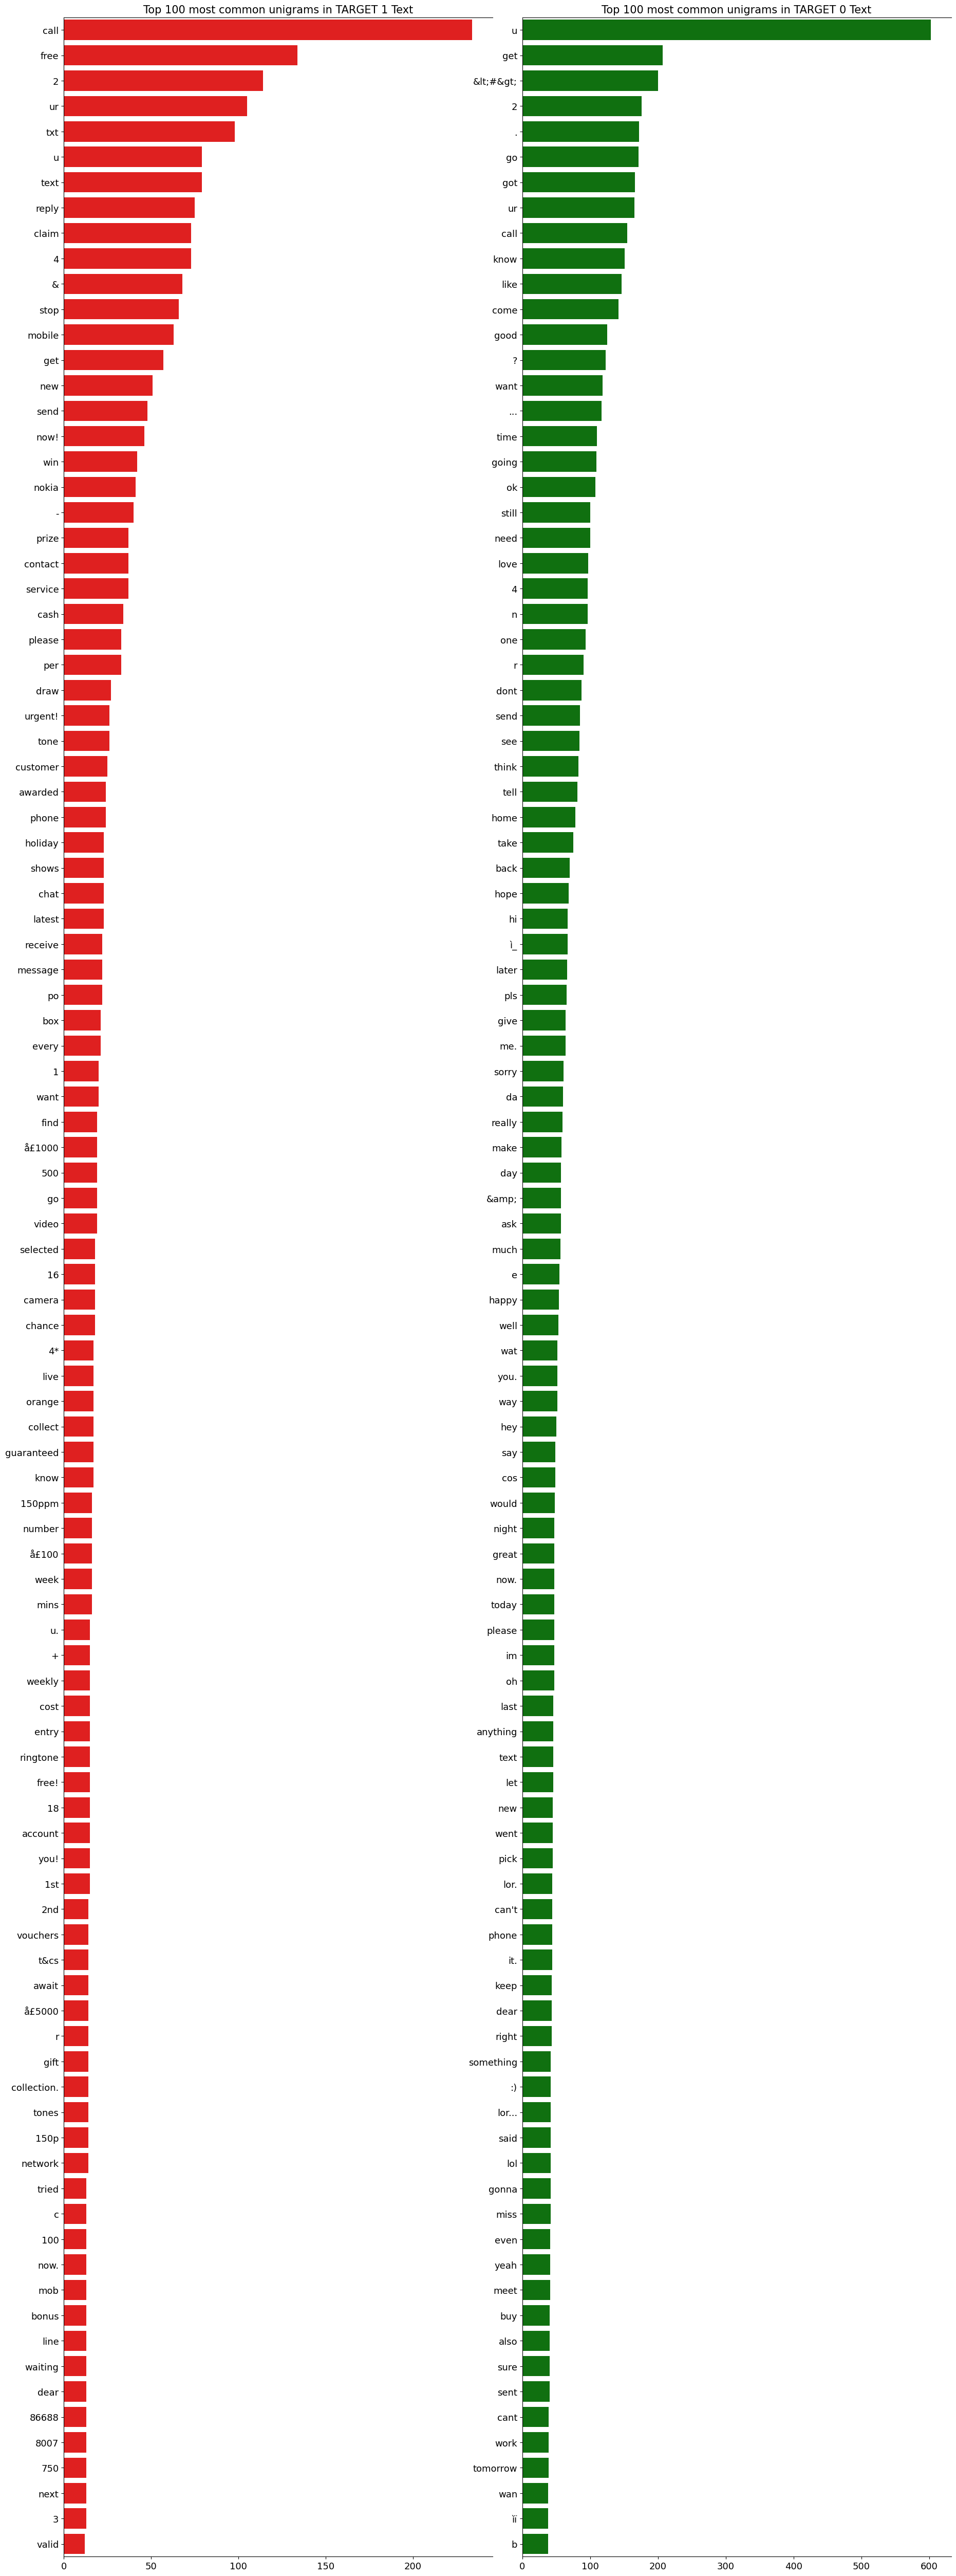

In [79]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 50), dpi=100)
plt.tight_layout()

sns.barplot(y=df_disaster_unigrams[0].values[:N], x=df_disaster_unigrams[1].values[:N], ax=axes[0], color='red')
sns.barplot(y=df_nondisaster_unigrams[0].values[:N], x=df_nondisaster_unigrams[1].values[:N], ax=axes[1], color='green')

for i in range(2):
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].tick_params(axis='y', labelsize=13)

axes[0].set_title(f'Top {N} most common unigrams in TARGET 1 Text', fontsize=15)
axes[1].set_title(f'Top {N} most common unigrams in TARGET 0 Text', fontsize=15)

plt.show()

 **Bigrams**

There are no common bigrams exist in both classes because the context is clearer.

Most common bigrams in disaster tweets are giving more information about the disasters than unigrams, but punctuations have to be stripped from words.

Most common bigrams in non-disaster tweets are mostly about reddit or youtube, and they contain lots of punctuations. Those punctuations have to be cleaned out of words as well.

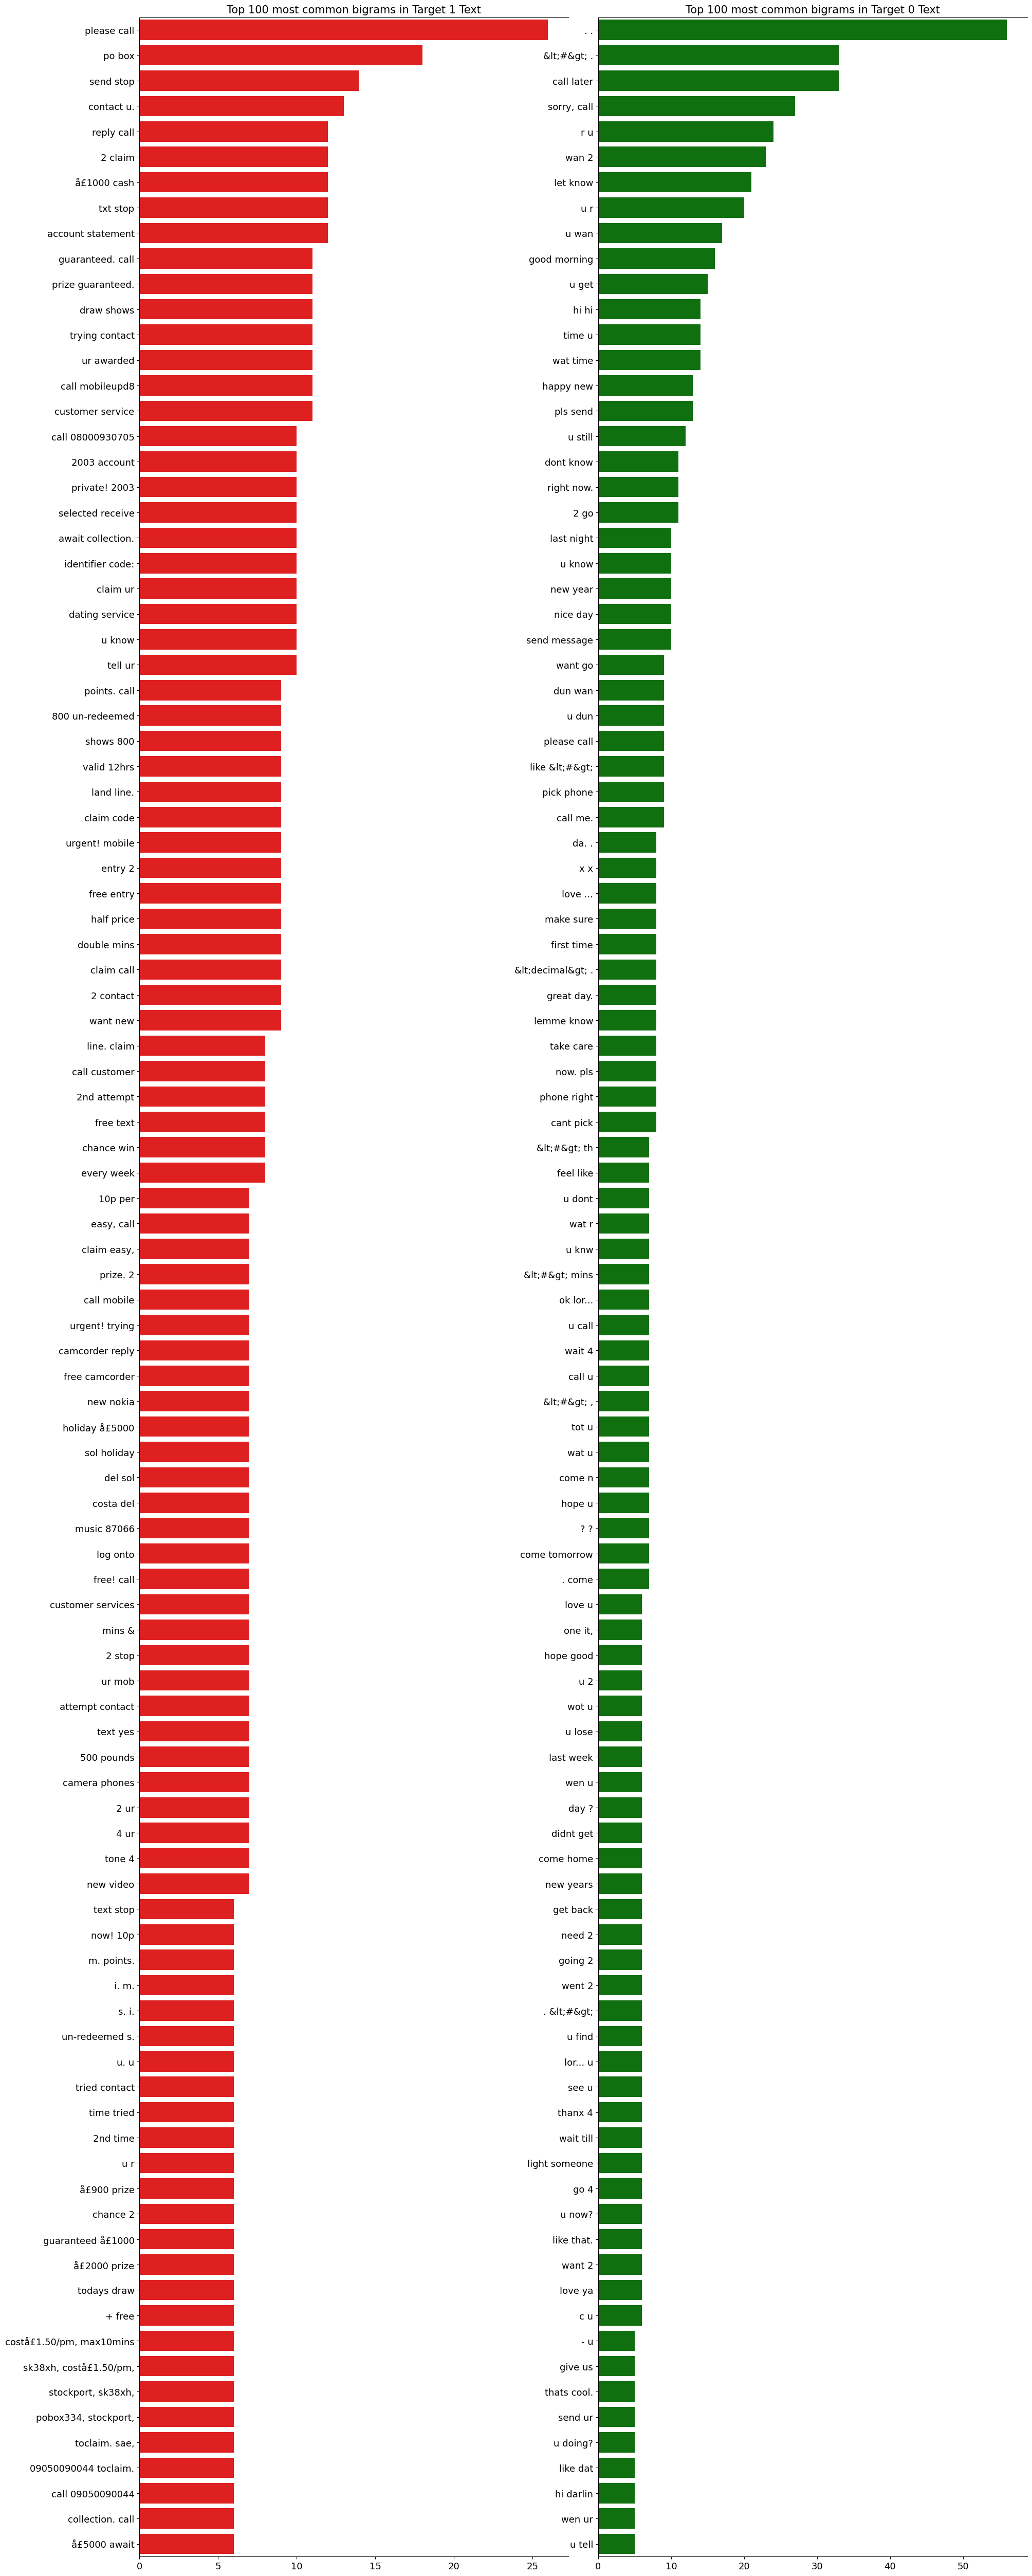

In [80]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 50), dpi=100)
plt.tight_layout()

sns.barplot(y=df_disaster_bigrams[0].values[:N], x=df_disaster_bigrams[1].values[:N], ax=axes[0], color='red')
sns.barplot(y=df_nondisaster_bigrams[0].values[:N], x=df_nondisaster_bigrams[1].values[:N], ax=axes[1], color='green')

for i in range(2):
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].tick_params(axis='y', labelsize=13)

axes[0].set_title(f'Top {N} most common bigrams in Target 1 Text', fontsize=15)
axes[1].set_title(f'Top {N} most common bigrams in Target 0 Text', fontsize=15)

plt.show()

**Trigrams**

There are no common trigrams exist in both classes because the context is clearer.

Most common trigrams in disaster tweets are very similar to bigrams. They give lots of information about disasters, but they may not provide any additional information along with bigrams.

Most common trigrams in non-disaster tweets are also very similar to bigrams, and they contain even more punctuations.

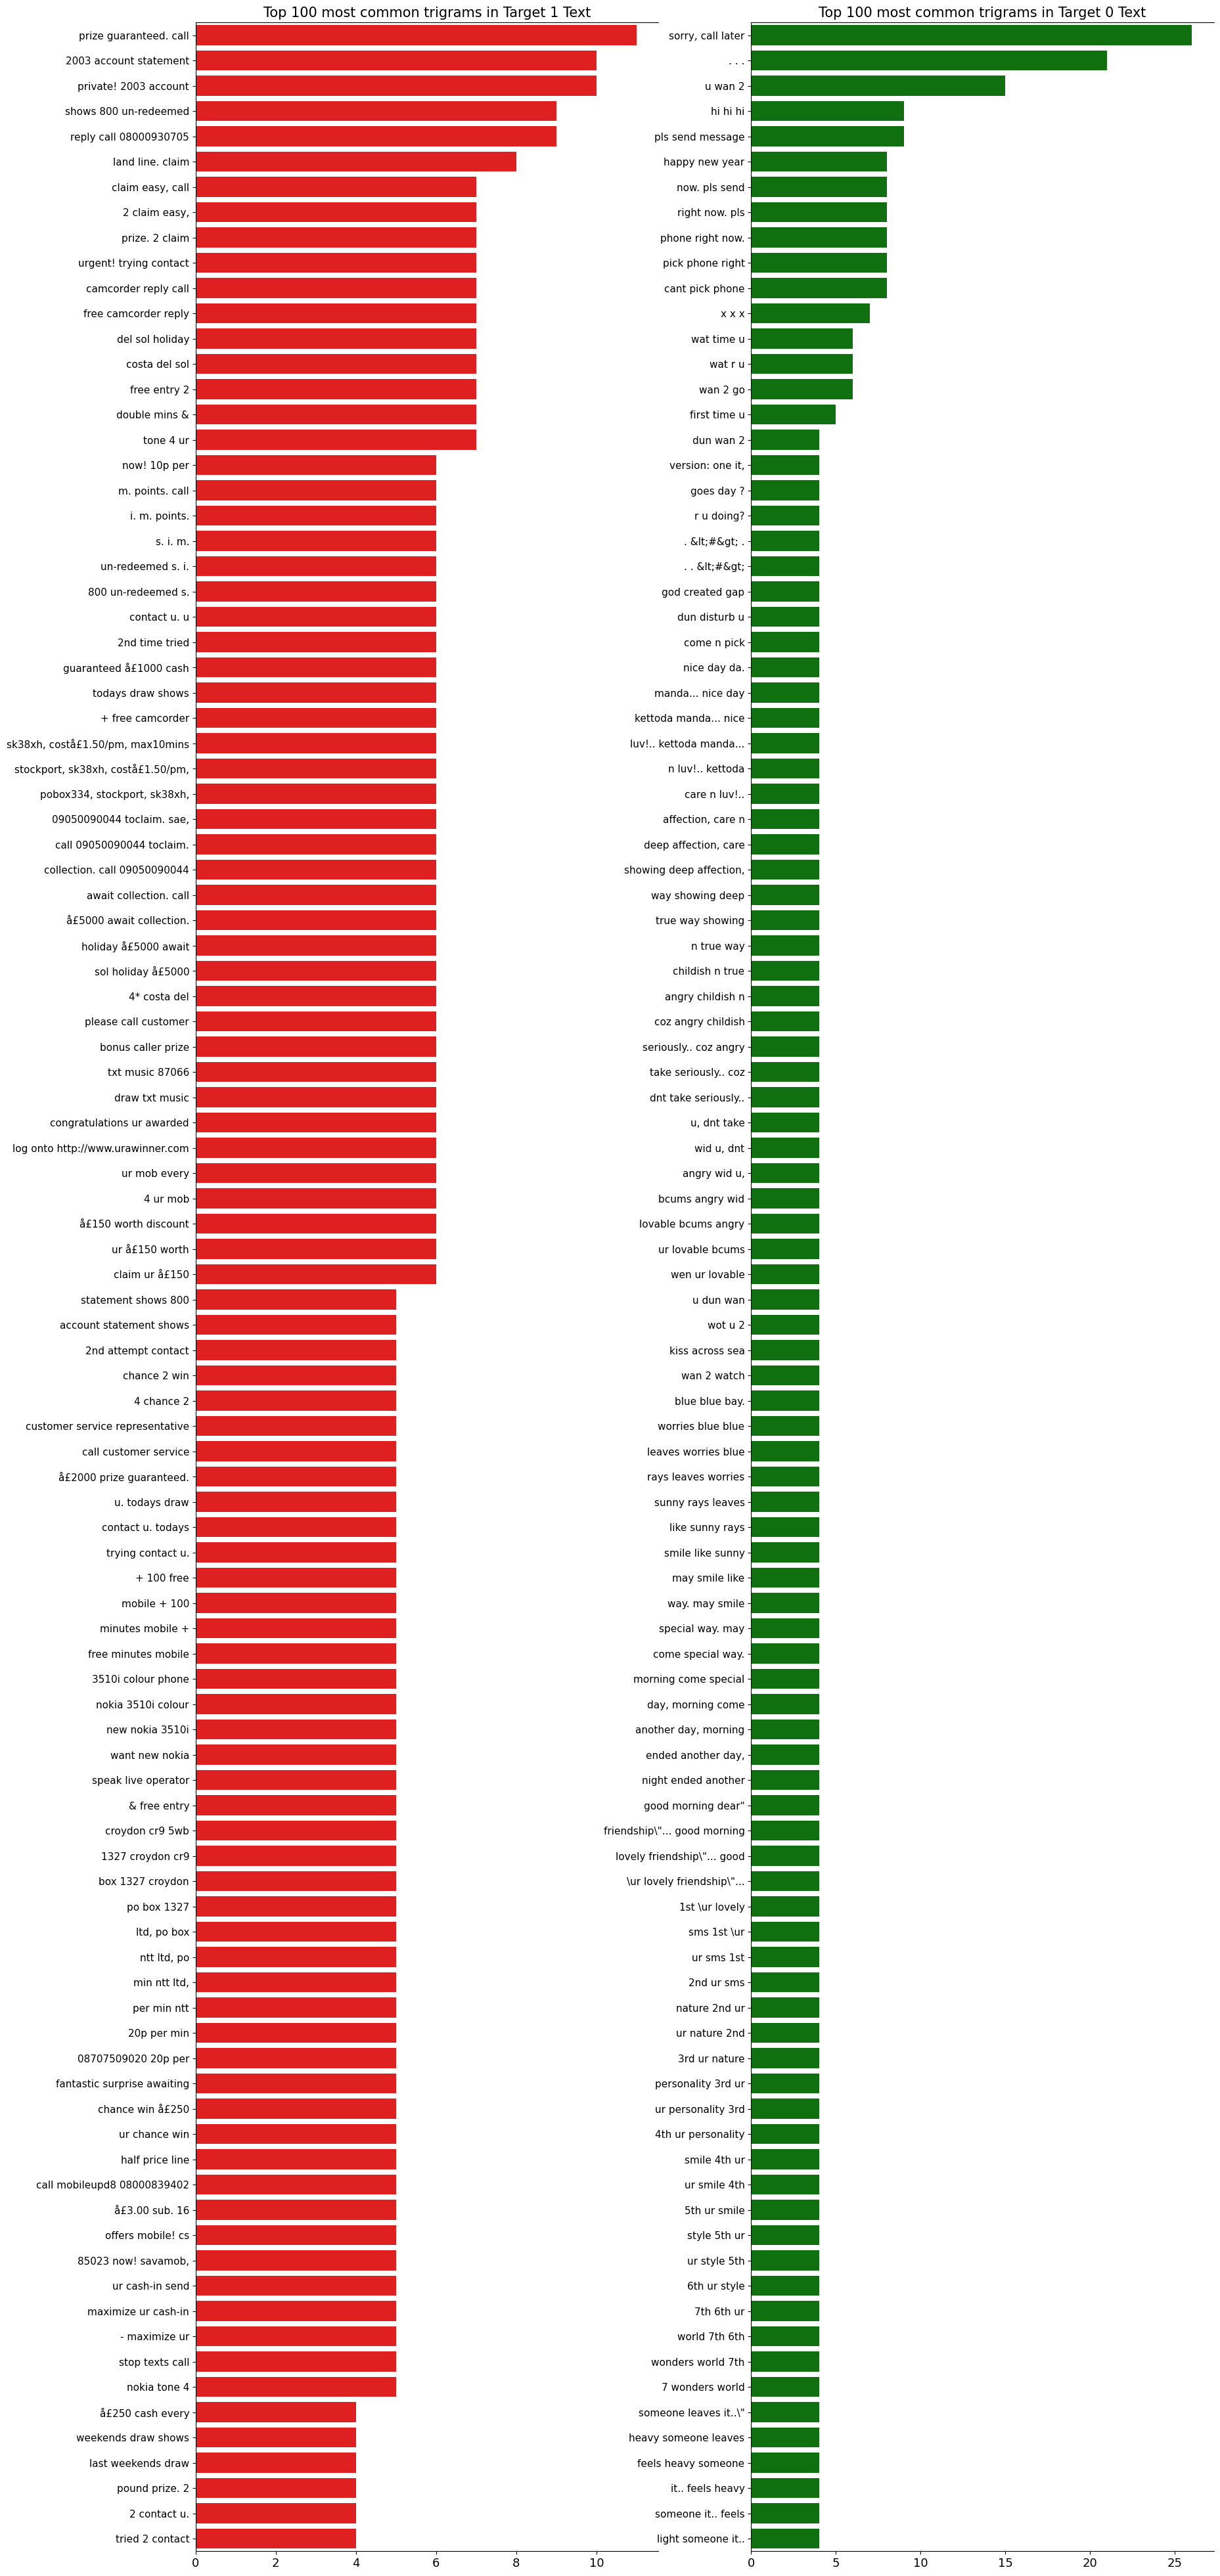

In [81]:


fig, axes = plt.subplots(ncols=2, figsize=(20, 50), dpi=100)

sns.barplot(y=df_disaster_trigrams[0].values[:N], x=df_disaster_trigrams[1].values[:N], ax=axes[0], color='red')
sns.barplot(y=df_nondisaster_trigrams[0].values[:N], x=df_nondisaster_trigrams[1].values[:N], ax=axes[1], color='green')

for i in range(2):
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].tick_params(axis='y', labelsize=11)

axes[0].set_title(f'Top {N} most common trigrams in Target 1 Text', fontsize=15)
axes[1].set_title(f'Top {N} most common trigrams in Target 0 Text', fontsize=15)

plt.show()



In [ ]:
# train.to_csv('train_clean.csv', index=False)  # index=False prevents writing row numbers
# test.to_csv('test_clean.csv', index=False)  # index=False prevents writing row numbers

In [17]:
%whos

Variable                  Type                    Data/Info
-----------------------------------------------------------
CountVectorizer           type                    <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
DISASTER_TWEETS           Series                  0       True\n1       Tru<...>Length: 7613, dtype: bool
LogisticRegression        type                    <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
METAFEATURES              list                    n=9
N                         int                     100
STOPWORDS                 set                     {"i'm", "wouldn't", 'shou<...>', 'hasn', "i'll", 'why'}
TfidfVectorizer           type                    <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
axes                      ndarray                 2: 2 elems, type `object`, 16 bytes
col                       str                     location
defaultdict               type                    <class 'collections.defaultdict'>
df           

In [82]:
import sys

for var_name in dir():
    if not var_name.startswith('_'):
        var_obj = globals()[var_name]
        print(var_name, sys.getsizeof(var_obj)/1024**2, "MB")

CountVectorizer 0.00141143798828125 MB
Counter 0.0010223388671875 MB
In 0.00075531005859375 MB
LogisticRegression 0.0010223388671875 MB
METAFEATURES 0.00012969970703125 MB
N 2.6702880859375e-05 MB
Out 0.00112152099609375 MB
STOPWORDS 0.00801849365234375 MB
TARGET_1 0.003856658935546875 MB
TfidfVectorizer 0.0010223388671875 MB
ax1 4.57763671875e-05 MB
ax2 4.57763671875e-05 MB
axes 0.0001068115234375 MB
col 5.245208740234375e-05 MB
corpus_0 0.38045501708984375 MB
corpus_1 0.10225677490234375 MB
count_punctuation 0.0001373291015625 MB
create_corpus 0.0001373291015625 MB
decode_map 0.00022125244140625 MB
decode_sentiment 0.0001373291015625 MB
defaultdict 0.00038909912109375 MB
df 0.3510580062866211 MB
df_disaster_bigrams 0.41275978088378906 MB
df_disaster_trigrams 0.4710550308227539 MB
df_disaster_unigrams 0.2082681655883789 MB
df_nondisaster_bigrams 1.5662422180175781 MB
df_nondisaster_trigrams 1.5898313522338867 MB
df_nondisaster_unigrams 0.5828075408935547 MB
disaster_bigrams 0.28134155